In [9]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data_processed = pd.read_csv('../data/clean_data/cleaned_processed_superstore_data.csv')
df = data_processed.copy()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   row_id              9994 non-null   int64  
 1   order_id            9994 non-null   str    
 2   order_date          9994 non-null   str    
 3   ship_date           9994 non-null   str    
 4   ship_mode           9994 non-null   str    
 5   customer_id         9994 non-null   str    
 6   customer_name       9994 non-null   str    
 7   segment             9994 non-null   str    
 8   country             9994 non-null   str    
 9   city                9994 non-null   str    
 10  state               9994 non-null   str    
 11  postal_code         9994 non-null   int64  
 12  region              9994 non-null   str    
 13  product_id          9994 non-null   str    
 14  category            9994 non-null   str    
 15  sub-category        9994 non-null   str    
 16  product_name     

In [7]:
df.describe()

,row_id,postal_code,sales,quantity,discount,profit,ship_time,order_year,order_month,profit_margin
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896,3.958175,2015.722233,7.809686,12.031393
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108,1.747567,1.123555,3.284654,46.675435
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.000000,2014.000000,1.000000,-275.000000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750,3.000000,2015.000000,5.000000,7.500000
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500,4.000000,2016.000000,9.000000,27.000000
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000,5.000000,2017.000000,11.000000,36.250000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000,7.000000,2017.000000,12.000000,50.000000


In [8]:
df.shape

(9994, 32)

## Section 1 — Overall Business KPIs


### KPI 1 — Total Sales


### Business Question
How much revenue did the company generate during the analyzed period?

In [10]:
total_sales = df["sales"].sum()
print(f"Total sales of the superstore is {total_sales}")

Total sales of the superstore is 2297200.8603


### Result
The company generated approximately $2.3 million in total sales.

### Interpretation
This represents the total revenue generated across all transactions in the dataset.

### KPI 2 — Total Profit


### Business Question 
How much profit did the company generate?

In [11]:
total_profit = df["profit"].sum()
print(f"Total profit of the superstore is {total_profit}")

Total profit of the superstore is 286397.0217


### Result
The company generated approximately $286'397 in total profit

### Interpretation
Although total sales represent the revenue generated, total profit represents the amount remaining after the costs captured in the dataset.

### KPI 3 — Total Orders


### Business Question 
How many orders did the company receive?

In [15]:
total_orders = df["order_id"].nunique()
print(f"Total order of the superstore is {total_orders}")

Total order of the superstore is 5009


### Result
The company has a total unique order of 5009

### Interpretation
The dataset contains 5009 unique customer order

### KPI 4 — Total Customers


### Business Question
How many unique customers did the company serve?

In [13]:
total_customers = df["customer_id"].nunique()
print(f"The superstore has {total_customers} customers")

The superstore has 793 customers


### Result
The company has 793 unique customers

### KPI 5 — Overall Profit Margin


### Business Question
What percentage of sales became profit?

In [14]:
overall_profit_margin = (total_profit/total_sales) * 100
print(overall_profit_margin)

12.467217240315605


### Result 
Overall profit margin is 12.5%

### Interpretation
For every $100 in sales, approximately $12.50 was retained as profit based on the profitability measure in the dataset.

### Business Implication
The company generates substantial revenue, but monitoring profitability is important because sales volume alone does not indicate how efficiently revenue is converted into profit.

### KPI Summary


In [16]:
kpi_summary = pd.DataFrame({
    'KPI': [
        'Total Sales',
        'Total Profit',
        'Total Orders',
        'Total Customers',
        'Overall Profit Margin'
    ],
    'Value': [
        total_sales,
        total_profit,
        total_orders,
        total_customers,
        overall_profit_margin
    ]
})

In [17]:
kpi_summary

,KPI,Value
0,Total Sales,2.297201e+06
1,Total Profit,2.863970e+05
2,Total Orders,5.009000e+03
3,Total Customers,7.930000e+02
4,Overall Profit Margin,1.246722e+01


## Section 2 — Sales Performance Over Time


In [19]:
yearly_table = (
    df.groupby("order_year")
      .agg(
          Total_Sales=("sales", "sum"),
          Total_Profit=("profit", "sum")
      )
      .reset_index()
)

yearly_table["Overall Profit Margin"] = (
    (yearly_table["Total_Profit"] / yearly_table["Total_Sales"]) * 100
).round(2)

yearly_table = yearly_table[["order_year", "Total_Sales", "Total_Profit", "Overall Profit Margin"]]

yearly_table

,order_year,Total_Sales,Total_Profit,Overall Profit Margin
0,2014,484247.4981,49543.9741,10.23
1,2015,470532.5090,61618.6037,13.10
2,2016,609205.5980,81795.1743,13.43
3,2017,733215.2552,93439.2696,12.74


### Q/A
#### Which year had the highest sales?
The year with the highest sales is 2017.
#### Which year had the highest profit?
The year with the highest profit is 2017.
#### Did sales increase or decrease each year?
Sales increased each year
#### Did profit follow the same pattern?
Yes the profit increased as the sales increased each year 
#### Did profitability improve or decline?
The profit improve during the years 

In [20]:
yearly_growth = yearly_table.sort_values("order_year").copy()

yearly_growth["Sales_YoY_Growth_%"] = (
    yearly_growth["Total_Sales"].pct_change().fillna(0) * 100
).round(2)

yearly_growth["Profit_YoY_Growth_%"] = (
    yearly_growth["Total_Profit"].pct_change().fillna(0) * 100
).round(2)

yearly_growth[["order_year", "Sales_YoY_Growth_%", "Profit_YoY_Growth_%"]]

,order_year,Sales_YoY_Growth_%,Profit_YoY_Growth_%
0,2014,0.00,0.00
1,2015,-2.83,24.37
2,2016,29.47,32.74
3,2017,20.36,14.24


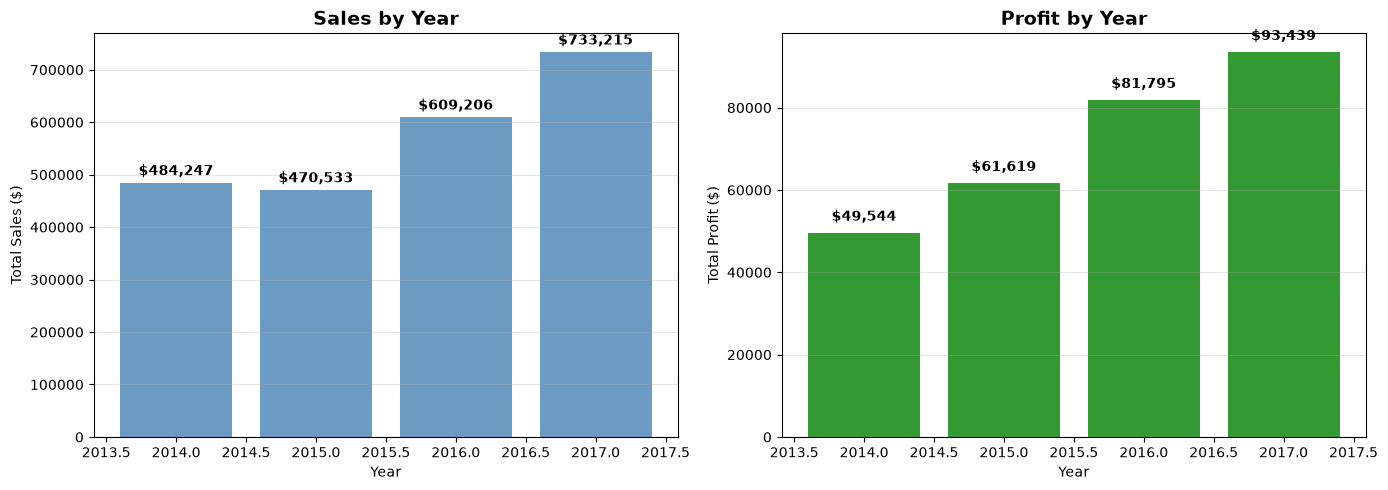

In [22]:
# Create visualizations for Sales and Profit by Year
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sales by Year
axes[0].bar(yearly_table["order_year"], yearly_table["Total_Sales"], color='steelblue', alpha=0.8)
axes[0].set_title('Sales by Year', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Total Sales ($)')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(yearly_table["Total_Sales"]):
    axes[0].text(yearly_table["order_year"].iloc[i], v + 15000, f'${v:,.0f}', ha='center', fontweight='bold')

# Profit by Year
axes[1].bar(yearly_table["order_year"], yearly_table["Total_Profit"], color='green', alpha=0.8)
axes[1].set_title('Profit by Year', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Total Profit ($)')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(yearly_table["Total_Profit"]):
    axes[1].text(yearly_table["order_year"].iloc[i], v + 3000, f'${v:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Interpretation 
Sales Trend: Sales show a strong upward trajectory, with a dip in 2015 (-2.83% YoY), followed by robust growth in 2016 (+29.47%) and continued growth in 2017 (+20.36%).
Profit Trend: Profit consistently increased every year, with particularly strong growth in 2015 (+24.37%) and 2016 (+32.74%), though growth moderated in 2017 (+14.24%).
Overall: Despite the slight sales decline in 2015, the company recovered and demonstrated strong business growth. Profit growth outpaced sales growth in early years, suggesting improving operational efficiency.

In [25]:
# Create monthly aggregation
monthly_table = (
    df.groupby(["order_year", "order_month", "order_month_name"])
      .agg(
          Total_Sales=("sales", "sum"),
          Total_Profit=("profit", "sum")
      )
      .reset_index()
)

monthly_table["Profit_Margin"] = (
    (monthly_table["Total_Profit"] / monthly_table["Total_Sales"]) * 100
).round(2)

# Create year-month combination for better plotting
monthly_table["Year_Month"] = monthly_table["order_year"].astype(str) + "-" + monthly_table["order_month"].astype(str).str.zfill(2)

monthly_table

,order_year,order_month,order_month_name,Total_Sales,Total_Profit,Profit_Margin,Year_Month
0,2014,1,January,14236.8950,2450.1907,17.21,2014-01
1,2014,2,February,4519.8920,862.3084,19.08,2014-02
2,2014,3,March,55691.0090,498.7299,0.90,2014-03
3,2014,4,April,28295.3450,3488.8352,12.33,2014-04
4,2014,5,May,23648.2870,2738.7096,11.58,2014-05
5,2014,6,June,34595.1276,4976.5244,14.39,2014-06
6,2014,7,July,33946.3930,-841.4826,-2.48,2014-07
7,2014,8,August,27909.4685,5318.1050,19.05,2014-08
8,2014,9,September,81777.3508,8328.0994,10.18,2014-09
9,2014,10,October,31453.3930,3448.2573,10.96,2014-10


## Section 3 — Profitability Analysis


### Category Profitability

#### Which product categories generate the most sales, profit, and profit margin?

In [26]:
category_sales_profit = (
    df.groupby('category')
      .agg(
          Total_Sales=("sales", "sum"),
          Total_Profit=("profit", "sum")
      )
      .reset_index()
)

category_sales_profit["Profit_Margin"] = (
    (category_sales_profit["Total_Profit"] / category_sales_profit["Total_Sales"]) * 100
).round(2)

category_sales_profit

,category,Total_Sales,Total_Profit,Profit_Margin
0,Furniture,741999.7953,18451.2728,2.49
1,Office Supplies,719047.0320,122490.8008,17.04
2,Technology,836154.0330,145454.9481,17.40


### Which category has the highest total sales?
The category with the highest sales is technology

### Which category has the highest total profit?
The category with the highest profit is technology

### Which category has the highest profit margin?
The category with the highest profit margin is technology

### Is the category with the highest sales also the category with the highest profit?
Yes

### Is the category with the highest profit also the category with the highest profit margin?
Yes


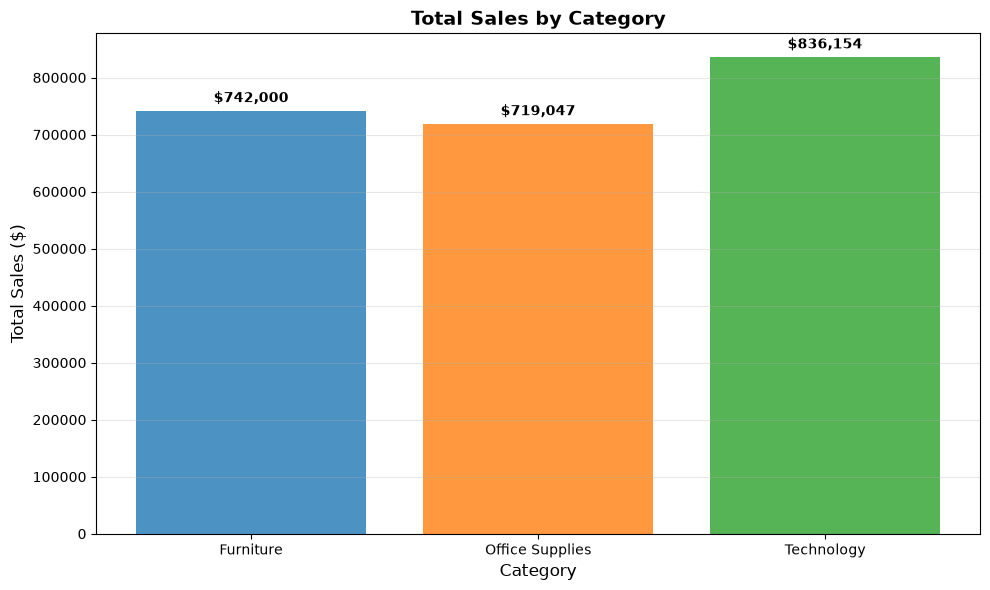

In [27]:
# Create a bar chart for Total Sales by Category
plt.figure(figsize=(10, 6))
plt.bar(category_sales_profit['category'], category_sales_profit['Total_Sales'], color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.8)
plt.title('Total Sales by Category', fontsize=14, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Add value labels on top of bars
for i, v in enumerate(category_sales_profit['Total_Sales']):
    plt.text(i, v + 15000, f'${v:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

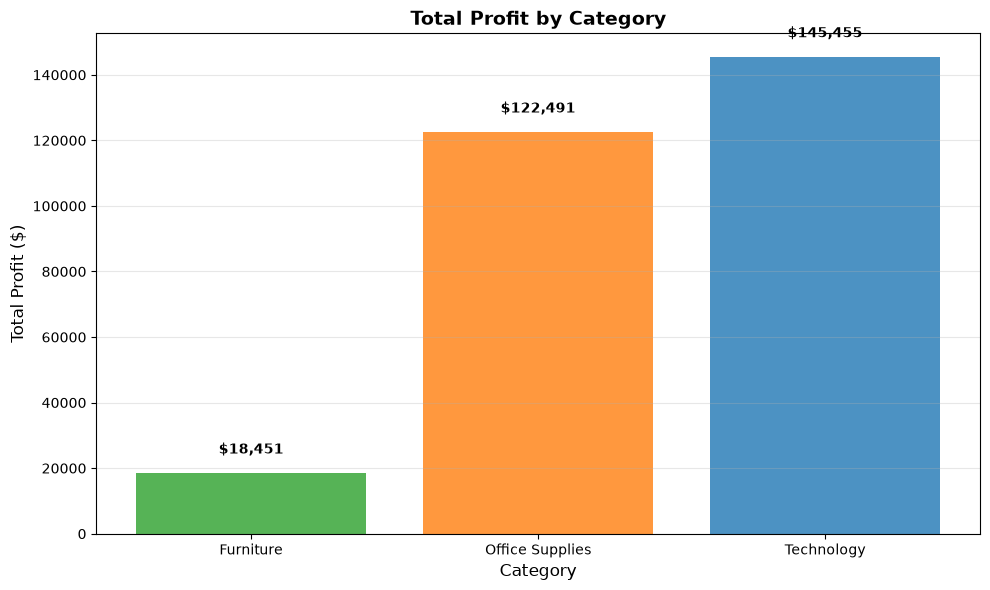

In [28]:
plt.figure(figsize=(10, 6))
bars = plt.bar(
    category_sales_profit["category"],
    category_sales_profit["Total_Profit"],
    color=["#2ca02c", "#ff7f0e", "#1f77b4"],
    alpha=0.8
)

plt.title("Total Profit by Category", fontsize=14, fontweight="bold")
plt.xlabel("Category", fontsize=12)
plt.ylabel("Total Profit ($)", fontsize=12)
plt.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, category_sales_profit["Total_Profit"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 5000,
        f'${value:,.0f}',
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

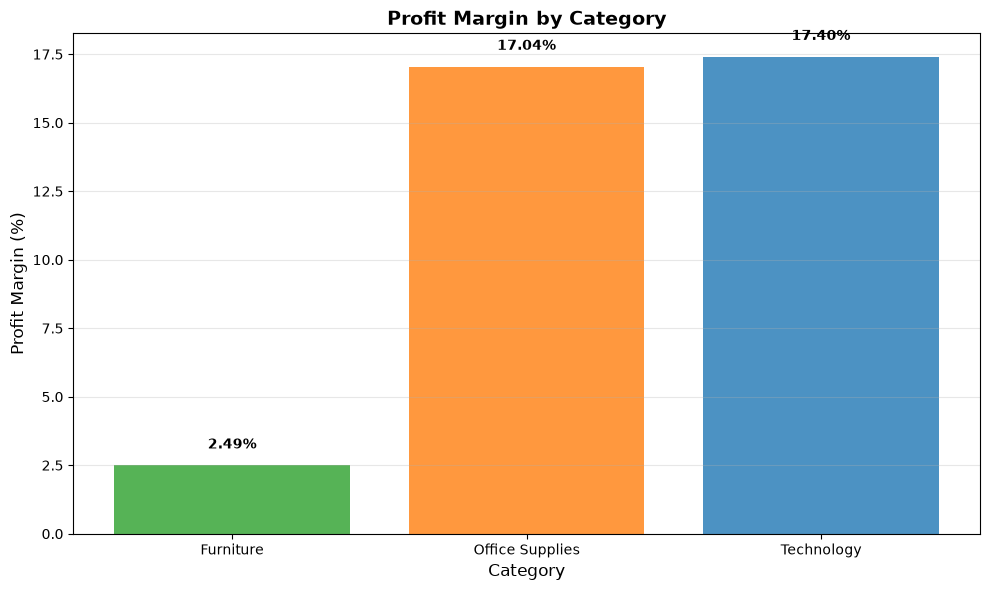

In [29]:
plt.figure(figsize=(10, 6))
bars = plt.bar(
    category_sales_profit["category"],
    category_sales_profit["Profit_Margin"],
    color=["#2ca02c", "#ff7f0e", "#1f77b4"],
    alpha=0.8
)

plt.title("Profit Margin by Category", fontsize=14, fontweight="bold")
plt.xlabel("Category", fontsize=12)
plt.ylabel("Profit Margin (%)", fontsize=12)
plt.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, category_sales_profit["Profit_Margin"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.5,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

## Profitability by Customer Segment


In [30]:
segment_profitability = (
    df.groupby('segment')
      .agg(
          Total_Sales=("sales", "sum"),
          Total_Profit=("profit", "sum")
      )
      .reset_index()
)

segment_profitability["Profit_Margin"] = (
    (segment_profitability["Total_Profit"] / segment_profitability["Total_Sales"]) * 100
).round(2)

segment_profitability

,segment,Total_Sales,Total_Profit,Profit_Margin
0,Consumer,1.161401e+06,134119.2092,11.55
1,Corporate,7.061464e+05,91979.1340,13.03
2,Home Office,4.296531e+05,60298.6785,14.03


### Which segment generates the highest total sales?
Consumer
### Which segment generates the highest total profit?
Consumer
### Which segment has the highest profit margin?
Consumer
### Does the segment with the highest sales also have the highest profit?
Yes
### Does the segment with the highest sales also have the highest profit margin?
No
### Which segment would you consider the most valuable, and why?
The most valuable segment i would consider home office because there is a 14% profit margin the highest 

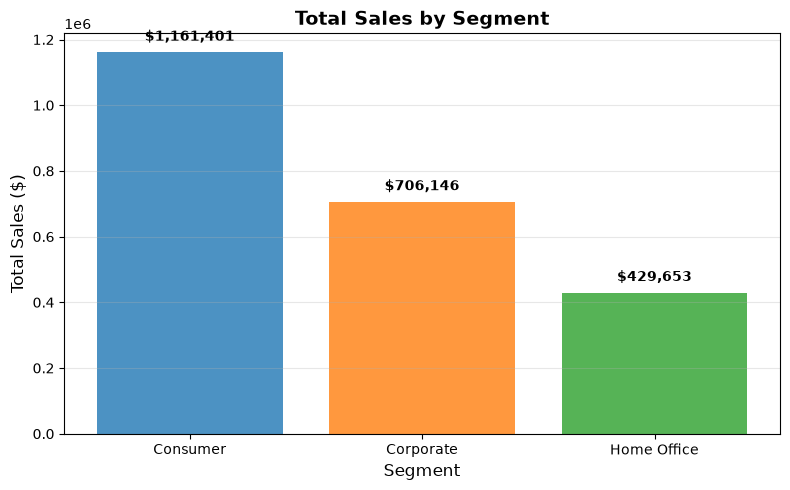

In [33]:
plt.figure(figsize=(8, 5))
bars = plt.bar(
    segment_profitability["segment"],
    segment_profitability["Total_Sales"],
    color=["#1f77b4", "#ff7f0e", "#2ca02c"],
    alpha=0.8
)

plt.title("Total Sales by Segment", fontsize=14, fontweight="bold")
plt.xlabel("Segment", fontsize=12)
plt.ylabel("Total Sales ($)", fontsize=12)
plt.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, segment_profitability["Total_Sales"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 25000,
        f"${value:,.0f}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

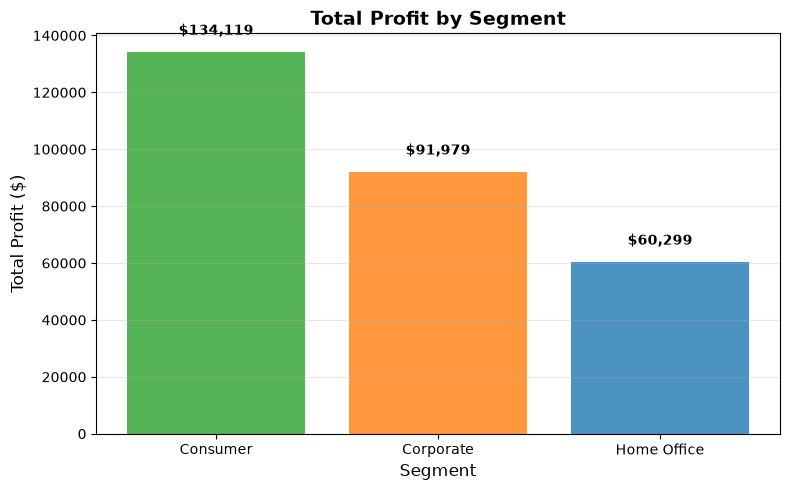

In [34]:
plt.figure(figsize=(8, 5))
bars = plt.bar(
    segment_profitability["segment"],
    segment_profitability["Total_Profit"],
    color=["#2ca02c", "#ff7f0e", "#1f77b4"],
    alpha=0.8
)

plt.title("Total Profit by Segment", fontsize=14, fontweight="bold")
plt.xlabel("Segment", fontsize=12)
plt.ylabel("Total Profit ($)", fontsize=12)
plt.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, segment_profitability["Total_Profit"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 5000,
        f"${value:,.0f}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

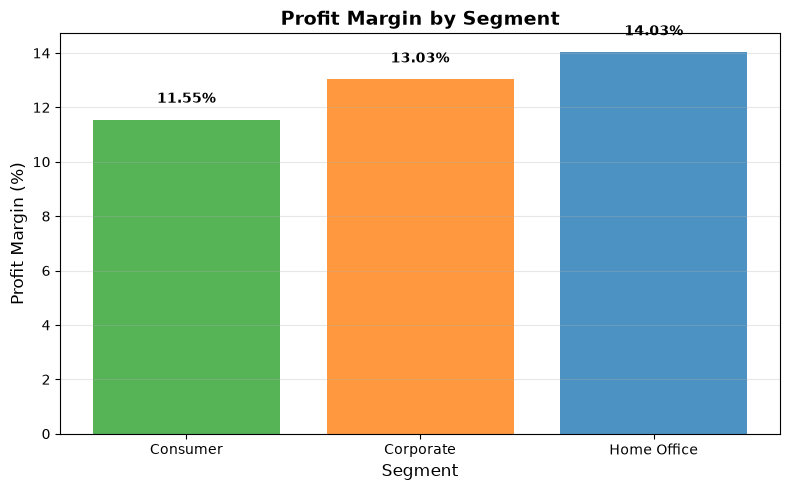

In [35]:
plt.figure(figsize=(8, 5))
bars = plt.bar(
    segment_profitability["segment"],
    segment_profitability["Profit_Margin"],
    color=["#2ca02c", "#ff7f0e", "#1f77b4"],
    alpha=0.8
)

plt.title("Profit Margin by Segment", fontsize=14, fontweight="bold")
plt.xlabel("Segment", fontsize=12)
plt.ylabel("Profit Margin (%)", fontsize=12)
plt.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, segment_profitability["Profit_Margin"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.5,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

## Loss-Making Areas

In [37]:
subcategory_analysis = (
    df.groupby("sub-category")
      .agg(
          Total_Sales=("sales", "sum"),
          Total_Profit=("profit", "sum"),
          Total_Quantity=("quantity", "sum")
          )
       .reset_index()
)

subcategory_analysis

,sub-category,Total_Sales,Total_Profit,Total_Quantity
0,Accessories,167380.3180,41936.6357,2976
1,Appliances,107532.1610,18138.0054,1729
2,Art,27118.7920,6527.7870,3000
3,Binders,203412.7330,30221.7633,5974
4,Bookcases,114879.9963,-3472.5560,868
5,Chairs,328449.1030,26590.1663,2356
6,Copiers,149528.0300,55617.8249,234
7,Envelopes,16476.4020,6964.1767,906
8,Fasteners,3024.2800,949.5182,914
9,Furnishings,91705.1640,13059.1436,3563


In [44]:
#Only loss making sub category 
loss_making_subcategories = subcategory_analysis[subcategory_analysis['Total_Profit']<0]
loss_making_subcategories.sort_values('Total_Profit')

,sub-category,Total_Sales,Total_Profit,Total_Quantity
16,Tables,206965.5320,-17725.4811,1241
4,Bookcases,114879.9963,-3472.5560,868
15,Supplies,46673.5380,-1189.0995,647


In [46]:
#Calculate profit margin of these categories 
loss_making_subcategories["Profit_Margin"] = (
    (loss_making_subcategories["Total_Profit"] / loss_making_subcategories["Total_Sales"]) * 100
).round(2)
loss_making_subcategories

,sub-category,Total_Sales,Total_Profit,Total_Quantity,Profit_Margin
4,Bookcases,114879.9963,-3472.5560,868,-3.02
15,Supplies,46673.5380,-1189.0995,647,-2.55
16,Tables,206965.5320,-17725.4811,1241,-8.56


#### Create the visualization

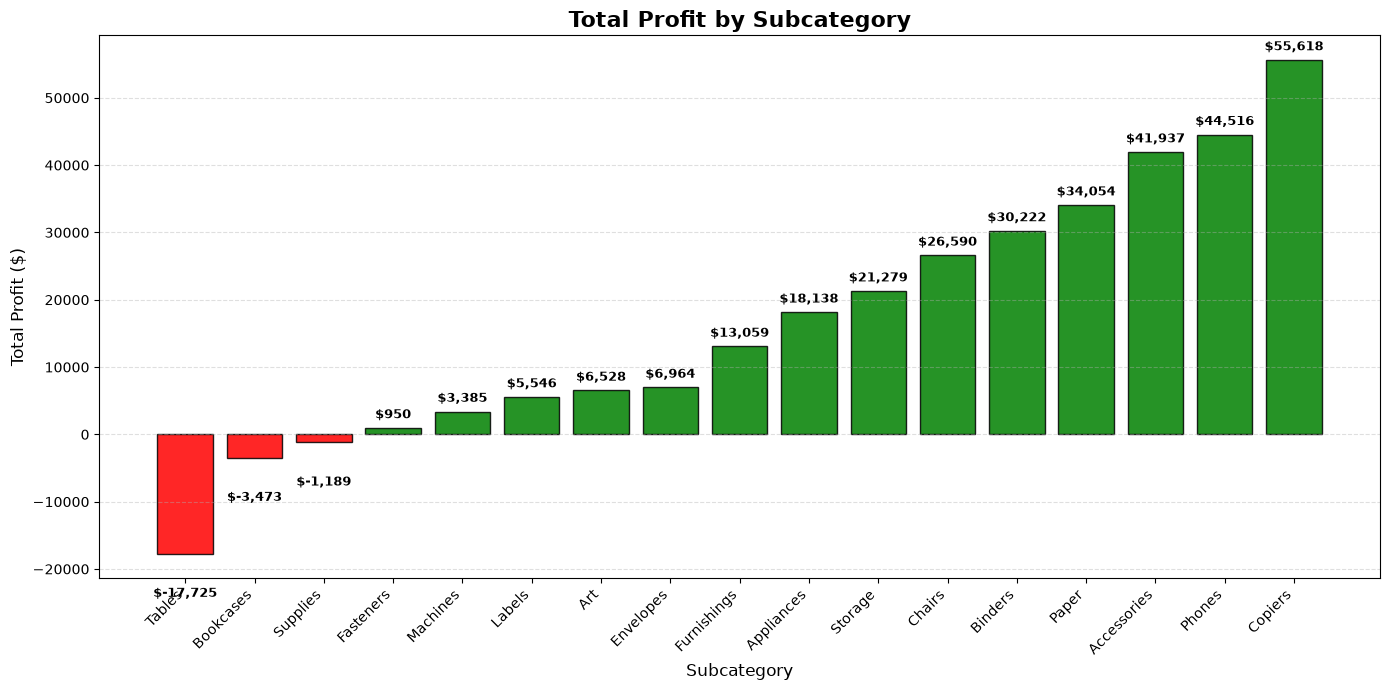

In [48]:
# Total Profit by Subcategory
subcategory_chart = subcategory_analysis.sort_values("Total_Profit").copy()

colors = ["green" if v >= 0 else "red" for v in subcategory_chart["Total_Profit"]]

plt.figure(figsize=(14, 7))
bars = plt.bar(
    subcategory_chart["sub-category"],
    subcategory_chart["Total_Profit"],
    color=colors,
    edgecolor="black",
    alpha=0.85
)

plt.title("Total Profit by Subcategory", fontsize=16, fontweight="bold")
plt.xlabel("Subcategory", fontsize=12)
plt.ylabel("Total Profit ($)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar, value in zip(bars, subcategory_chart["Total_Profit"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + (1000 if value >= 0 else -5000),
        f"${value:,.0f}",
        ha="center",
        va="bottom" if value >= 0 else "top",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

## Section 4 — Product Performance Strategy


In [66]:
product_performance = (
    df.groupby(["product_name", "category", "sub-category"], dropna=False)
      .agg(
          Total_Sales=("sales", "sum"),
          Total_Profit=("profit", "sum"),
          Total_Quantity=("quantity", "sum"),
          Number_of_Orders=("order_id", "nunique")
      )
      .reset_index()
)

product_performance["Profit_Margin"] = (
    (product_performance["Total_Profit"] / product_performance["Total_Sales"]) * 100
).round(2)

product_performance = product_performance.rename(columns={"sub-category": "sub_category"})
product_performance = product_performance[
    ["product_name", "category", "sub_category", "Total_Sales", "Total_Profit", "Total_Quantity", "Number_of_Orders", "Profit_Margin"]
].rename(columns={
    "Number_of_Orders": "Number of Orders",
    "Total_Sales": "Total Sales",
    "Total_Profit": "Total Profit",
    "Total_Quantity": "Total Quantity",
    "Profit_Margin": "Profit Margin"
})

product_performance_sales_top_10 = product_performance.sort_values("Total Sales", ascending=False).reset_index(drop=True)
product_performance_sales_top_10

,product_name,category,sub_category,Total Sales,Total Profit,Total Quantity,Number of Orders,Profit Margin
0,Canon imageCLASS 2200 Advanced Copier,Technology,Copiers,61599.824,2.519993e+04,20,5,40.91
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,Binders,27453.384,7.753039e+03,31,10,28.24
2,Cisco TelePresence System EX90 Videoconferenci...,Technology,Machines,22638.480,-1.811078e+03,6,1,-8.00
3,HON 5400 Series Task Chairs for Big and Tall,Furniture,Chairs,21870.576,5.684342e-14,39,8,0.00
4,GBC DocuBind TL300 Electric Binding System,Office Supplies,Binders,19823.479,2.233505e+03,37,11,11.27
...,...,...,...,...,...,...,...,...
1845,Avery Hi-Liter Pen Style Six-Color Fluorescent...,Office Supplies,Art,7.700,3.157000e+00,2,1,41.00
1846,Grip Seal Envelopes,Office Supplies,Envelopes,7.072,2.386800e+00,2,1,33.75
1847,Xerox 20,Office Supplies,Paper,6.480,3.110400e+00,1,1,48.00
1848,Avery 5,Office Supplies,Labels,5.760,2.822400e+00,2,1,49.00


In [56]:
product_performance_margin_top_10 = product_performance.sort_values("Profit Margin", ascending=False).reset_index(drop=True)
product_performance.head(10)

,product_name,category,sub_category,Total Sales,Total Profit,Total Quantity,Number of Orders,Profit Margin
0,Southworth Structures Collection,Office Supplies,Paper,72.80,36.4000,10,2,50.0
1,Xerox 1890,Office Supplies,Paper,244.70,122.3500,5,2,50.0
2,Tops Green Bar Computer Printout Paper,Office Supplies,Paper,342.58,171.2900,7,3,50.0
3,Avery 475,Office Supplies,Labels,266.40,133.2000,18,4,50.0
4,Adams Telephone Message Book w/Frequently-Call...,Office Supplies,Paper,223.44,111.7200,28,7,50.0
5,Canon imageCLASS MF7460 Monochrome Digital Las...,Technology,Machines,3991.98,1995.9900,2,1,50.0
6,Xerox 1918,Office Supplies,Paper,155.04,75.9696,4,1,49.0
7,Avery 478,Office Supplies,Labels,88.38,43.3062,18,4,49.0
8,Personal Creations Ink Jet Cards and Labels,Office Supplies,Paper,321.44,157.5056,28,4,49.0
9,Ativa V4110MDD Micro-Cut Shredder,Technology,Machines,7699.89,3772.9461,11,2,49.0


In [63]:
product_performance_profit_top_10 = product_performance.sort_values("Total Profit", ascending=False).reset_index(drop=True)
product_performance.head(10)

,product_name,category,sub_category,Total Sales,Total Profit,Total Quantity,Number of Orders,Profit Margin,product_performance_group
0,Southworth Structures Collection,Office Supplies,Paper,72.80,36.4000,10,2,50.0,Weak Product
1,Xerox 1890,Office Supplies,Paper,244.70,122.3500,5,2,50.0,Hidden Gem
2,Tops Green Bar Computer Printout Paper,Office Supplies,Paper,342.58,171.2900,7,3,50.0,Star
3,Avery 475,Office Supplies,Labels,266.40,133.2000,18,4,50.0,Hidden Gem
4,Adams Telephone Message Book w/Frequently-Call...,Office Supplies,Paper,223.44,111.7200,28,7,50.0,Hidden Gem
5,Canon imageCLASS MF7460 Monochrome Digital Las...,Technology,Machines,3991.98,1995.9900,2,1,50.0,Star
6,Xerox 1918,Office Supplies,Paper,155.04,75.9696,4,1,49.0,Hidden Gem
7,Avery 478,Office Supplies,Labels,88.38,43.3062,18,4,49.0,Weak Product
8,Personal Creations Ink Jet Cards and Labels,Office Supplies,Paper,321.44,157.5056,28,4,49.0,Star
9,Ativa V4110MDD Micro-Cut Shredder,Technology,Machines,7699.89,3772.9461,11,2,49.0,Star


#### Which products generate the highest sales?
Canon imageCLASS 2200 Advanced Copier
#### Which products generate the highest profit?
Canon imageCLASS 2200 Advanced Copier
#### Which products have the highest profit margin?
There are 6 product with the 50% profit margin Southworth Structures Collection , Xerox 1890 , Tops Green Bar Computer Printout Paper , Avery 475 , Adams Telephone Message Book , Canon imageCLASS MF7460 Monochrome

In [59]:

sales_median = product_performance["Total Sales"].median()
profit_median = product_performance["Total Profit"].median()

sales_high = product_performance["Total Sales"] >= sales_median
profit_high = product_performance["Total Profit"] >= profit_median

conditions = [
    sales_high & profit_high,        # High Sales + High Profit
    sales_high & ~profit_high,       # High Sales + Low Profit
    ~sales_high & profit_high,       # Low Sales + High Profit
    ~sales_high & ~profit_high       # Low Sales + Low Profit
]

labels = [
    "Star",
    "Risky Revenue",
    "Hidden Gem",
    "Weak Product"
]

product_performance["product_performance_group"] = np.select(
    conditions,
    labels,
    default="Weak Product"
)

product_performance

,product_name,category,sub_category,Total Sales,Total Profit,Total Quantity,Number of Orders,Profit Margin,product_performance_group
0,Southworth Structures Collection,Office Supplies,Paper,72.800,36.4000,10,2,50.00,Weak Product
1,Xerox 1890,Office Supplies,Paper,244.700,122.3500,5,2,50.00,Hidden Gem
2,Tops Green Bar Computer Printout Paper,Office Supplies,Paper,342.580,171.2900,7,3,50.00,Star
3,Avery 475,Office Supplies,Labels,266.400,133.2000,18,4,50.00,Hidden Gem
4,Adams Telephone Message Book w/Frequently-Call...,Office Supplies,Paper,223.440,111.7200,28,7,50.00,Hidden Gem
...,...,...,...,...,...,...,...,...,...
1845,Zebra GK420t Direct Thermal/Thermal Transfer P...,Technology,Machines,703.710,-938.2800,6,1,-133.33,Risky Revenue
1846,Okidata B401 Printer,Technology,Machines,179.991,-251.9874,3,1,-140.00,Weak Product
1847,Euro Pro Shark Stick Mini Vacuum,Office Supplies,Appliances,170.744,-325.6332,11,3,-190.71,Weak Product
1848,"Bush Westfield Collection Bookcases, Dark Cher...",Furniture,Bookcases,90.882,-190.8522,3,1,-210.00,Weak Product


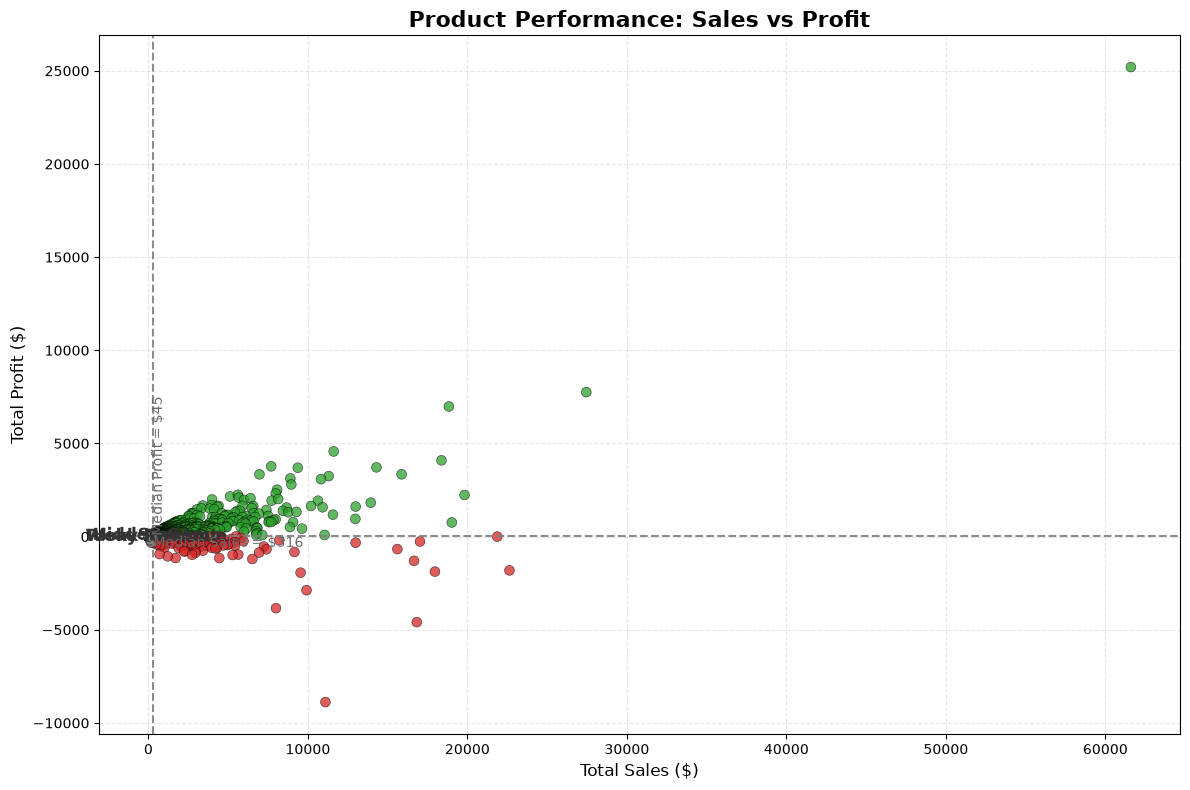

In [62]:
# Scatter plot: product-level sales vs profit
sales_median = product_performance["Total Sales"].median()
profit_median = product_performance["Total Profit"].median()

# Optional color by product performance group
group_colors = {
    "Star": "#2ca02c",
    "Risky Revenue": "#d62728",
    "Hidden Gem": "#ff7f0e",
    "Weak Product": "#7f7f7f"
}
point_colors = product_performance["product_performance_group"].map(group_colors).fillna("#7f7f7f")

fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(
    product_performance["Total Sales"],
    product_performance["Total Profit"],
    s=50,
    c=point_colors,
    alpha=0.75,
    edgecolor="black",
    linewidth=0.4
)

# Median reference lines
ax.axvline(sales_median, color="gray", linestyle="--", linewidth=1.5, alpha=0.9)
ax.axhline(profit_median, color="gray", linestyle="--", linewidth=1.5, alpha=0.9)

# Quadrant labels
ax.text(
    sales_median * 0.65,
    profit_median * 1.55,
    "Hidden Gem",
    fontsize=12,
    color="#333",
    ha="center",
    va="center",
    weight="bold"
)
ax.text(
    sales_median * 1.75,
    profit_median * 1.55,
    "Star",
    fontsize=12,
    color="#333",
    ha="center",
    va="center",
    weight="bold"
)
ax.text(
    sales_median * 0.65,
    profit_median * 0.35,
    "Weak Product",
    fontsize=12,
    color="#333",
    ha="center",
    va="center",
    weight="bold"
)
ax.text(
    sales_median * 1.75,
    profit_median * 0.35,
    "Risky Revenue",
    fontsize=12,
    color="#333",
    ha="center",
    va="center",
    weight="bold"
)

# Axis labels and title
ax.set_title("Product Performance: Sales vs Profit", fontsize=16, fontweight="bold")
ax.set_xlabel("Total Sales ($)", fontsize=12)
ax.set_ylabel("Total Profit ($)", fontsize=12)

# Grid and annotation styling
ax.grid(True, linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

# Add median line annotations
ax.text(
    sales_median * 1.02,
    profit_median * 0.92,
    f"Median Sales = ${sales_median:,.0f}",
    fontsize=10,
    color="dimgray",
    ha="left",
    va="top"
)
ax.text(
    sales_median * 0.5,
    profit_median * 1.02,
    f"Median Profit = ${profit_median:,.0f}",
    fontsize=10,
    color="dimgray",
    ha="left",
    va="bottom",
    rotation=90
)

plt.tight_layout()
plt.show()

## Section 5: Cross-Analysis & Root Cause Investigation

### Losses by Subcategory + Region

In [71]:
subcategory_region_analysis = (
    df.groupby(["region", "sub-category"])
    .agg(
        Total_Sales=("sales", "sum"),
        Total_Profit=("profit", "sum"),
        Total_Quantity=("quantity", "sum"),
        Total_Orders=("order_id", "nunique")
    )
    .reset_index()
)

subcategory_region_analysis["Profit_Margin"] = (
    subcategory_region_analysis["Total_Profit"]
    / subcategory_region_analysis["Total_Sales"]
) * 100

subcategory_region_analysis

,region,sub-category,Total_Sales,Total_Profit,Total_Quantity,Total_Orders,Profit_Margin
0,Central,Accessories,33956.0760,7251.6306,716,172,21.355915
1,Central,Appliances,23582.0330,-2638.6175,470,119,-11.189101
2,Central,Art,5765.3400,1195.1591,678,165,20.730071
3,Central,Binders,56923.2820,-1043.6369,1473,318,-1.833410
4,Central,Bookcases,24157.1768,-1997.9043,192,49,-8.270438
...,...,...,...,...,...,...,...
63,West,Paper,26663.7180,12119.2364,1702,384,45.452162
64,West,Phones,98684.3520,9110.7426,1068,256,9.232206
65,West,Storage,70532.8520,8645.3222,1039,247,12.257157
66,West,Supplies,18127.1220,626.0465,238,68,3.453645


In [76]:
loss_making_subcategory_regions = subcategory_region_analysis[
    subcategory_region_analysis["Total_Profit"] < 0
].sort_values("Total_Profit")

loss_making_subcategory_regions

,region,sub-category,Total_Sales,Total_Profit,Total_Quantity,Total_Orders,Profit_Margin
33,East,Tables,39139.8070,-11025.3801,271,76,-28.169224
50,South,Tables,43916.1920,-4623.0579,227,49,-10.527001
9,Central,Furnishings,15254.3700,-3906.2168,758,191,-25.607198
16,Central,Tables,39154.9710,-3559.6504,262,68,-9.091184
1,Central,Appliances,23582.0330,-2638.6175,470,119,-11.189101
4,Central,Bookcases,24157.1768,-1997.9043,192,49,-8.270438
55,West,Bookcases,36004.1235,-1646.5117,306,79,-4.573120
11,Central,Machines,26797.3840,-1486.0666,66,20,-5.545566
45,South,Machines,53890.9600,-1438.8930,62,17,-2.670008
21,East,Bookcases,43819.3340,-1167.6318,252,68,-2.664650


#### Which subcategory + region combinations generate losses?
Tables from all the region generate losses  but on east region generate the most losses 
#### Which combination creates the largest total loss?
Table + east region
#### Does the same subcategory perform differently across regions?
No

### Profitability by Discount Level

In [77]:
discount_analysis = (
    df.groupby("discount_category")
    .agg(
        Total_Sales=("sales", "sum"),
        Total_Profit=("profit", "sum"),
        Total_Quantity=("quantity", "sum"),
        Transactions=("order_id", "count")
    )
    .reset_index()
)

discount_analysis["Profit_Margin"] = (
    discount_analysis["Total_Profit"]
    / discount_analysis["Total_Sales"]
) * 100

discount_analysis

,discount_category,Total_Sales,Total_Profit,Total_Quantity,Transactions,Profit_Margin
0,High Discount,6.422874e+04,-76559.0513,3349,856,-119.197502
1,Low Discount,8.465222e+05,100785.4745,14231,3803,11.905827
2,Medium Discount,2.985414e+05,-58817.0047,2026,537,-19.701456
3,No Discount,1.087908e+06,320987.6032,18267,4798,29.505019


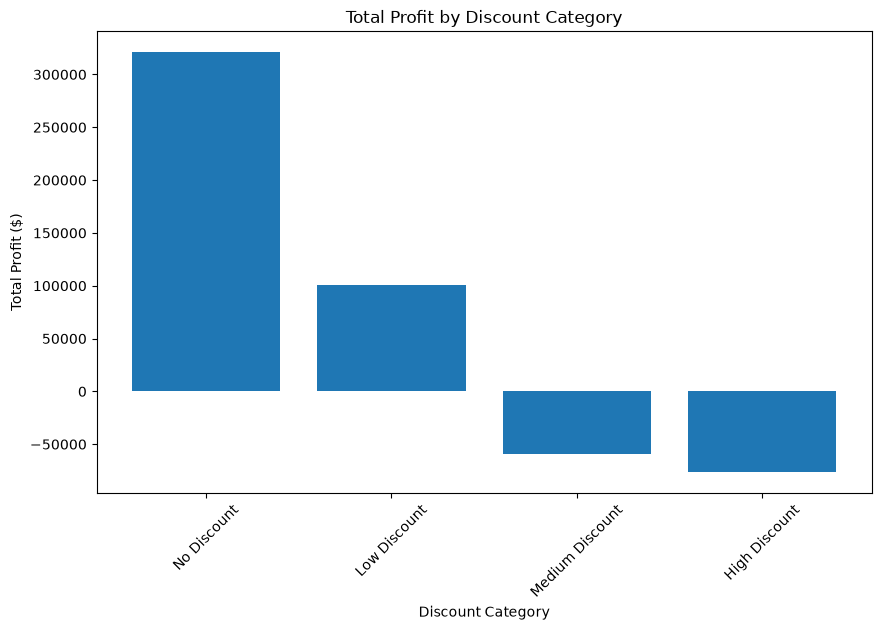

In [81]:
# Chart 1 - Total Profit by Discount Category
plt.figure(figsize=(10, 6))

plt.bar(
    discount_analysis["discount_category"],
    discount_analysis["Total_Profit"]
)

plt.title("Total Profit by Discount Category")
plt.xlabel("Discount Category")
plt.ylabel("Total Profit ($)")
plt.xticks(rotation=45)

plt.show()

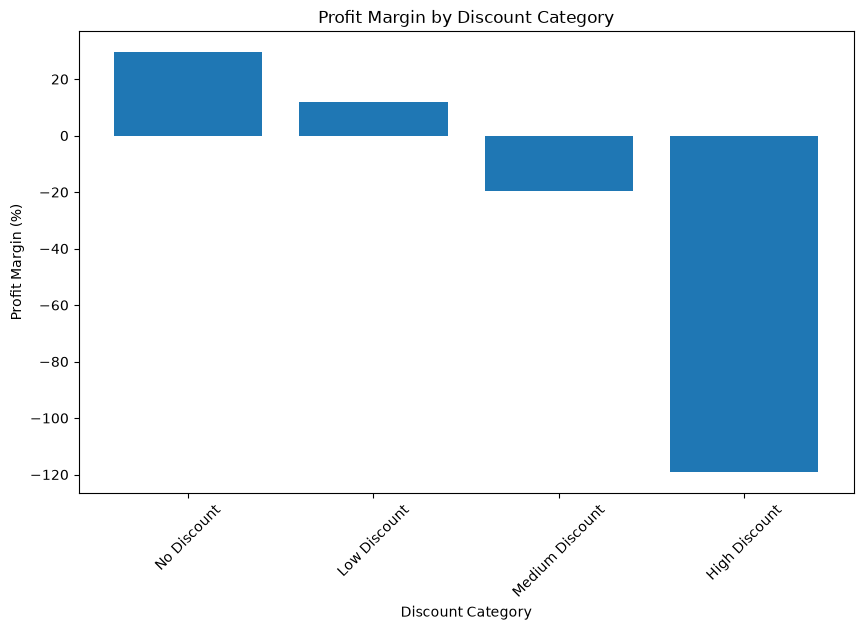

In [82]:
# Chart 2 - Profit Margin by Discount Category
plt.figure(figsize=(10, 6))

plt.bar(
    discount_analysis["discount_category"],
    discount_analysis["Profit_Margin"]
)

plt.title("Profit Margin by Discount Category")
plt.xlabel("Discount Category")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=45)

plt.show()

#### Which discount category generates the highest total profit?
No discount category generate the highest total profit 320987.6032	
#### Which generates the lowest or negative profit?
High discount genereate the lowest negative profit -76559.0513	
#### Does profit margin generally decrease as discounts increase?
Yes
#### Are higher discounts associated with weaker profitability?
Higher discount levels are associated with lower profitability.

### Subcategory + Discount Risk Investigation

In [84]:
subcategory_discount_analysis = (
    df.groupby(["sub-category", "discount_category"])
    .agg(
        Total_Sales=("sales", "sum"),
        Total_Profit=("profit", "sum"),
        Total_Quantity=("quantity", "sum"),
        Transactions=("order_id", "count")
    )
    .reset_index()
)

subcategory_discount_analysis["Profit_Margin"] = (
    subcategory_discount_analysis["Total_Profit"]
    / subcategory_discount_analysis["Total_Sales"]
) * 100

subcategory_discount_analysis

,sub-category,discount_category,Total_Sales,Total_Profit,Total_Quantity,Transactions,Profit_Margin
0,Accessories,Low Discount,49010.0080,6647.3818,1141,304,13.563315
1,Accessories,No Discount,118370.3100,35289.2539,1835,471,29.812589
2,Appliances,High Discount,3382.5340,-8629.6412,235,67,-255.123561
3,Appliances,Low Discount,26083.4370,3583.9105,473,128,13.740177
4,Appliances,No Discount,78066.1900,23183.7361,1021,271,29.697538
5,Art,Low Discount,9104.1520,1147.1864,1096,298,12.600695
6,Art,No Discount,18014.6400,5380.6006,1904,498,29.867933
7,Binders,High Discount,36140.6130,-38510.4964,2456,613,-106.557397
8,Binders,Low Discount,85442.6400,29417.8090,2227,573,34.429892
9,Binders,No Discount,81829.4800,39314.4507,1291,337,48.044361


In [85]:
#Loss making 
loss_making_discount_combinations = (
    subcategory_discount_analysis[
        subcategory_discount_analysis["Total_Profit"] < 0
    ]
    .sort_values("Total_Profit")
)

loss_making_discount_combinations

,sub-category,discount_category,Total_Sales,Total_Profit,Total_Quantity,Transactions,Profit_Margin
7,Binders,High Discount,36140.6130,-38510.4964,2456,613,-106.557397
43,Tables,Medium Discount,89956.5400,-30698.2228,650,176,-34.125615
29,Machines,High Discount,15601.5090,-19579.3191,89,23,-125.496316
31,Machines,Medium Discount,61237.5990,-9976.0330,91,30,-16.290699
2,Appliances,High Discount,3382.5340,-8629.6412,235,67,-255.123561
12,Bookcases,Medium Discount,26084.6168,-7202.8220,224,55,-27.613294
15,Chairs,Medium Discount,70005.5020,-6737.1167,614,158,-9.623696
36,Phones,Medium Discount,34337.3520,-6385.7854,414,109,-18.597198
24,Furnishings,High Discount,6644.7000,-5944.6552,501,138,-89.464614
38,Storage,Low Discount,65989.8480,-4249.3451,1114,316,-6.439392


In [87]:
#piviot table
profit_pivot = subcategory_discount_analysis.pivot(
    index="sub-category",
    columns="discount_category",
    values="Total_Profit"
)

profit_pivot

discount_category,High Discount,Low Discount,Medium Discount,No Discount
sub-category,,,,
Accessories,NaN,6647.3818,NaN,35289.2539
Appliances,-8629.6412,3583.9105,NaN,23183.7361
Art,NaN,1147.1864,NaN,5380.6006
Binders,-38510.4964,29417.8090,NaN,39314.4507
Bookcases,-3894.9394,1549.4937,-7202.8220,6075.7117
Chairs,NaN,11394.1869,-6737.1167,21933.0961
Copiers,NaN,17878.7148,2182.9752,35556.1349
Envelopes,NaN,1987.1923,NaN,4976.9844
Fasteners,NaN,297.3130,NaN,652.2052


### Root Cause Summary

| Business Problem        | Evidence      | Possible Driver                       | Recommendation                               |
| ----------------------- | ------------- | ------------------------------------- | -------------------------------------------- |
| Loss-making subcategory | Actual result | High discounts / regional differences | Investigate pricing and discount policy      |
| Regional loss           | Actual result | Location-specific performance         | Review regional strategy                     |
| High sales, low profit  | Actual result | Weak margins                          | Review profitability before increasing sales |


Cross-analysis revealed that losses are not uniformly distributed across the business. Certain subcategories and products perform differently depending on region and discount level. The strongest risk areas are the combinations that generate substantial sales but negative profit. These findings suggest that management should investigate pricing, discount policies, and regional performance rather than evaluating products only at an overall level.